# Notebook 03: Viola-Jones + Entrenamiento YOLOv8
**Entorno:** Local (VS Code) — CPU 


## 1. Verificacion del entorno local

In [5]:
import torch
import cv2
import sys
import platform
import os
from pathlib import Path

print("  INFORME DEL ENTORNO")
print(f"  Sistema:    {platform.system()} {platform.release()}")
print(f"  Python:     {sys.version.split()[0]}")
print(f"  PyTorch:    {torch.__version__}")
print(f"  OpenCV:     {cv2.__version__}")
print()

# Verificar dispositivo disponible
if torch.cuda.is_available():
    device = "cuda"
    gpu_name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  GPU CUDA:   {gpu_name} ({vram:.1f} GB VRAM)")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
    print("  GPU MPS:    Apple Silicon (Metal Performance Shaders)")
else:
    device = "cpu"
    cpu_count = os.cpu_count()
    print(f"  Dispositivo: CPU ({cpu_count} nucleos)")
    print()
    

print()
print(f"  Dispositivo seleccionado: {device}")

# Verificar rutas del proyecto
DATASET_PATH = Path("data/clean")
MODEL_OUT    = Path("models")
RESULTS_PATH = Path("results/reports")

for p in [DATASET_PATH, MODEL_OUT, RESULTS_PATH]:
    p.mkdir(parents=True, exist_ok=True)

yaml_ok    = (DATASET_PATH / "data.yaml").exists()
train_ok   = (DATASET_PATH / "train" / "images").exists()

print(f"  data/clean/data.yaml: {'OK' if yaml_ok  else 'NO ENCONTRADO'}")
print(f"  data/clean/train/:    {'OK' if train_ok  else 'NO ENCONTRADO'}")

  INFORME DEL ENTORNO
  Sistema:    Windows 10
  Python:     3.11.0
  PyTorch:    2.12.0+cpu
  OpenCV:     4.13.0

  Dispositivo: CPU (12 nucleos)


  Dispositivo seleccionado: cpu
  data/clean/data.yaml: OK
  data/clean/train/:    OK


## 2. Instalacion de dependencias

In [6]:
# Instalar si no estan disponibles
#pip install ultralytics==8.2.18 albumentations==1.4.6 pyyaml tqdm -q

import yaml
import json
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
from ultralytics import YOLO

# Leer clases del dataset
with open("data/clean/data.yaml") as f:
    cfg = yaml.safe_load(f)
CLASSES = cfg["names"]
N       = len(CLASSES)

print(f"Ultralytics cargado correctamente")
print(f"Clases ({N}): {CLASSES}")

Ultralytics cargado correctamente
Clases (9): ['acne', 'dark circle', 'darkspot', 'dry', 'normal skin', 'oily', 'pores', 'skin redness', 'wrinkle']


In [ ]:
#  Semilla global para reproducibilidad 
# Fija todas las fuentes de aleatoriedad del proyecto para que cualquier
# ejecucion del notebook produzca exactamente los mismos resultados.

# Fuentes controladas:
#   - random        : seleccion de muestras visuales, shuffle en copy-paste
#   - numpy         : operaciones matriciales aleatorias
#   - torch         : inicializacion de pesos, dropout, augmentation interna
#   - YOLO seed     : se pasa en TRAIN_CONFIG["seed"] (ya incluido)
#   - albumentations: usa numpy internamente, queda cubierto por np.seed

SEED = 123

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Forzar operaciones deterministas en PyTorch cuando es posible.
torch.use_deterministic_algorithms(True, warn_only=True)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

print(f"Semilla global fijada: SEED={SEED}")
print(f"Todas las operaciones aleatorias son reproducibles.")

Semilla global fijada: SEED=123
Todas las operaciones aleatorias son reproducibles.


## 3. Viola-Jones: Funciones de deteccion y preprocesado

Viola-Jones detecta el rostro y devuelve la bbox. Se usa para recortar la region facial antes de pasarsela a YOLOv8, reduciendo el area de
busqueda y mejorando la precision de deteccion de lesiones.

In [4]:
# Cargar clasificador Haar preentrenado de OpenCV
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

VJ_PARAMS = {
    "scaleFactor":  1.1,
    "minNeighbors": 5,
    "minSize":      (60, 60),
}

def detect_face_vj(img_bgr, params=VJ_PARAMS):
    """
    Detecta el rostro mas grande con Viola-Jones.
    La ecualizacion del histograma mejora la deteccion en piel
    oscura o baja iluminacion antes de aplicar el cascade.
    Devuelve (x, y, w, h) o None si no hay deteccion.
    """
    gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray  = cv2.equalizeHist(gray)
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor  = params["scaleFactor"],
        minNeighbors = params["minNeighbors"],
        minSize      = params["minSize"]
    )
    if len(faces) == 0:
        return None
    return max(faces, key=lambda f: f[2] * f[3])


def crop_face(img_bgr, x, y, w, h, padding=40, target_size=640):
    """
    Recorta el rostro con padding y redimensiona a target_size x target_size.
    El padding da contexto perimetral necesario para detectar ojeras,
    manchas en mejillas y arrugas en el contorno facial.
    """
    ih, iw = img_bgr.shape[:2]
    x1 = max(0, x - padding)
    y1 = max(0, y - padding)
    x2 = min(iw, x + w + padding)
    y2 = min(ih, y + h + padding)
    crop = img_bgr[y1:y2, x1:x2]
    crop = cv2.resize(crop, (target_size, target_size),
                      interpolation=cv2.INTER_LANCZOS4)
    return crop, (x1, y1, x2, y2)


def scale_bbox_to_crop(bbox_yolo, orig_shape, crop_coords, target_size=640):
    """
    Reescala una bbox YOLO del espacio de la imagen original
    al espacio del crop facial tras aplicar Viola-Jones.
    Devuelve (cx, cy, bw, bh) normalizados o None si queda fuera del crop.
    """
    oh, ow        = orig_shape
    x1c, y1c, x2c, y2c = crop_coords
    cw = x2c - x1c
    ch = y2c - y1c

    cx_abs = bbox_yolo[0] * ow
    cy_abs = bbox_yolo[1] * oh
    bw_abs = bbox_yolo[2] * ow
    bh_abs = bbox_yolo[3] * oh

    x1b = cx_abs - bw_abs / 2
    y1b = cy_abs - bh_abs / 2
    x2b = cx_abs + bw_abs / 2
    y2b = cy_abs + bh_abs / 2

    x1b_c = max(x1b, x1c) - x1c
    y1b_c = max(y1b, y1c) - y1c
    x2b_c = min(x2b, x2c) - x1c
    y2b_c = min(y2b, y2c) - y1c

    if x2b_c <= x1b_c or y2b_c <= y1b_c:
        return None

    new_cx = min(max(((x1b_c + x2b_c) / 2) / cw, 0.0), 1.0)
    new_cy = min(max(((y1b_c + y2b_c) / 2) / ch, 0.0), 1.0)
    new_bw = min(max((x2b_c - x1b_c) / cw,         0.0), 1.0)
    new_bh = min(max((y2b_c - y1b_c) / ch,         0.0), 1.0)

    if new_bw * new_bh < 0.001:
        return None

    return (new_cx, new_cy, new_bw, new_bh)

print("Funciones de Viola-Jones definidas.")

Funciones de Viola-Jones definidas.


## 4. Test visual de Viola-Jones

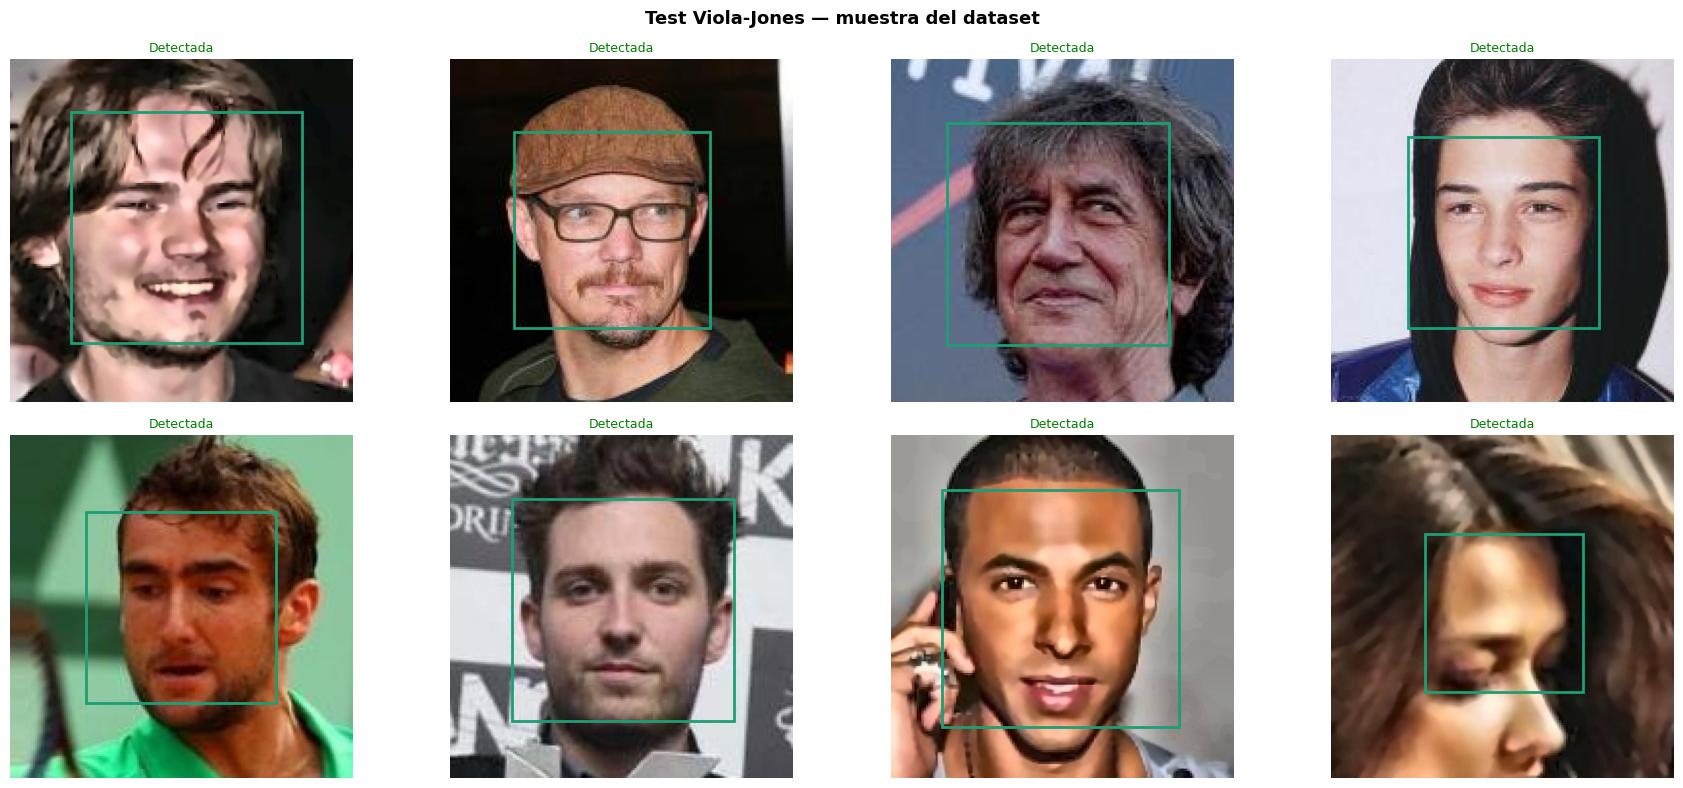

Detectadas:    8/8
No detectadas: 0/8

Si hay muchas sin detectar, bajar minNeighbors a 3 en VJ_PARAMS.


In [5]:
# Probar la deteccion sobre una muestra del train antes de aplicar a todo
sample_dir = Path("data/clean/train/images")
sample_imgs = random.sample(
    list(sample_dir.glob("*.jpg")), min(8, len(list(sample_dir.glob("*.jpg"))))
)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Test Viola-Jones — muestra del dataset", fontsize=13, fontweight="bold")

detected = undetected = 0
for ax, img_path in zip(axes.flat, sample_imgs):
    img     = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    face    = detect_face_vj(img)

    if face is not None:
        x, y, w, h = face
        rect = patches.Rectangle((x, y), w, h,
               linewidth=2, edgecolor="#1D9E75", facecolor="none")
        ax.add_patch(rect)
        ax.set_title("Detectada", fontsize=9, color="green")
        detected += 1
    else:
        ax.set_title("No detectada", fontsize=9, color="red")
        undetected += 1

    ax.imshow(img_rgb)
    ax.axis("off")

plt.tight_layout()
plt.savefig("results/reports/vj_test.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Detectadas:    {detected}/8")
print(f"No detectadas: {undetected}/8")
print()
print("Si hay muchas sin detectar, bajar minNeighbors a 3 en VJ_PARAMS.")

## 5. Aplicar Viola-Jones al dataset completo

In [6]:
# Dataset de salida con crops faciales
VJ_OUTPUT  = Path("data/clean_vj")
PADDING_VJ = 40

for split in ["train", "valid", "test"]:
    (VJ_OUTPUT / split / "images").mkdir(parents=True, exist_ok=True)
    (VJ_OUTPUT / split / "labels").mkdir(parents=True, exist_ok=True)

stats = defaultdict(int)

for split in ["train", "valid", "test"]:
    img_dir = Path("data/clean") / split / "images"
    lbl_dir = Path("data/clean") / split / "labels"
    out_img = VJ_OUTPUT / split / "images"
    out_lbl = VJ_OUTPUT / split / "labels"

    img_files = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))

    for img_path in tqdm(img_files, desc=f"VJ {split}"):
        img = cv2.imread(str(img_path))
        if img is None:
            stats["error_lectura"] += 1
            continue

        lbl_path = lbl_dir / (img_path.stem + ".txt")
        orig_h, orig_w = img.shape[:2]
        face = detect_face_vj(img)

        if face is not None:
            x, y, w, h = face
            crop, crop_coords = crop_face(img, x, y, w, h, PADDING_VJ)
            stats[f"{split}_cropped"] += 1
        else:
            crop        = cv2.resize(img, (640, 640), interpolation=cv2.INTER_LANCZOS4)
            crop_coords = (0, 0, orig_w, orig_h)
            stats[f"{split}_no_face"] += 1

        cv2.imwrite(str(out_img / img_path.name), crop,
                    [cv2.IMWRITE_JPEG_QUALITY, 95])

        if lbl_path.exists():
            new_lines = []
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    cls_id   = int(parts[0])
                    bbox     = tuple(map(float, parts[1:]))
                    new_bbox = scale_bbox_to_crop(
                        bbox, (orig_h, orig_w), crop_coords
                    )
                    if new_bbox is not None:
                        cx, cy, bw, bh = new_bbox
                        new_lines.append(
                            f"{cls_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}"
                        )
            with open(out_lbl / (img_path.stem + ".txt"), "w") as f:
                f.write("\n".join(new_lines))

shutil.copy("data/clean/data.yaml", VJ_OUTPUT / "data.yaml")

with open(VJ_OUTPUT / "data.yaml") as f:
    vcfg = yaml.safe_load(f)
vcfg["path"]  = str(VJ_OUTPUT.resolve())
vcfg["train"] = "train/images"
vcfg["val"]   = "valid/images"
vcfg["test"]  = "test/images"
with open(VJ_OUTPUT / "data.yaml", "w") as f:
    yaml.dump(vcfg, f, default_flow_style=False)

print("Viola-Jones completado:")
for k, v in sorted(stats.items()):
    print(f"  {k:30s}: {v}")

VJ test: 100%|██████████| 412/412 [00:49<00:00,  8.27it/s]

Viola-Jones completado:
  test_cropped                  : 138
  test_no_face                  : 274
  train_cropped                 : 39523
  train_no_face                 : 4564
  valid_cropped                 : 339
  valid_no_face                 : 527


## 6. Calcular class weights

In [9]:
def count_annotations(path, splits):
    counts = defaultdict(int)
    for split in splits:
        ldir = Path(path) / split / "labels"
        if not ldir.exists():
            continue
        for lf in ldir.glob("*.txt"):
            for line in open(lf):
                p = line.strip().split()
                if p:
                    counts[int(p[0])] += 1
    return counts

counts = count_annotations(VJ_OUTPUT, ["train"])
total  = sum(counts[i] for i in range(N))


In [7]:
def count_annotations(path, splits):
    counts = defaultdict(int)
    for split in splits:
        ldir = Path(path) / split / "labels"
        if not ldir.exists():
            continue
        for lf in ldir.glob("*.txt"):
            for line in open(lf):
                p = line.strip().split()
                if p:
                    counts[int(p[0])] += 1
    return counts

counts = count_annotations(VJ_OUTPUT, ["train"])
total  = sum(counts[i] for i in range(N))

print("Anotaciones de train por clase:")
for i, cls in enumerate(CLASSES):
    n   = counts[i]
    pct = 100 * n / total if total else 0
    bar = "#" * int(pct / 2)
    print(f"  [{i}] {cls:15s} {n:6d}  {pct:5.1f}%  {bar}")

# Pesos inversos a la frecuencia, normalizados (media = 1.0), capped a 10
raw_w = [total / (N * max(counts.get(i, 1), 1)) for i in range(N)]
mean_w = sum(raw_w) / N
class_weights = [min(round(w / mean_w, 4), 10.0) for w in raw_w]

print("\nClass weights (max=10):")
for i, (cls, w) in enumerate(zip(CLASSES, class_weights)):
    print(f"  [{i}] {cls:15s}  {w}")

with open(VJ_OUTPUT / "data.yaml") as f:
    vcfg = yaml.safe_load(f)
vcfg["weight"] = class_weights
with open(VJ_OUTPUT / "data.yaml", "w") as f:
    yaml.dump(vcfg, f, default_flow_style=False, allow_unicode=True)

print("\ndata.yaml actualizado con class weights.")

Anotaciones de train por clase:
  [0] acne             10040   16.4%  ########
  [1] dark circle      18609   30.4%  ###############
  [2] darkspot          5666    9.3%  ####
  [3] dry               1780    2.9%  #
  [4] normal skin      22006   36.0%  #################
  [5] oily              1090    1.8%  
  [6] pores              440    0.7%  
  [7] skin redness        76    0.1%  
  [8] wrinkle           1501    2.5%  #

Class weights (max=10):
  [0] acne             0.0499
  [1] dark circle      0.0269
  [2] darkspot         0.0885
  [3] dry              0.2817
  [4] normal skin      0.0228
  [5] oily             0.46
  [6] pores            1.1394
  [7] skin redness     6.5968
  [8] wrinkle          0.334

data.yaml actualizado con class weights.


## 7. Copy-paste augmentation para clases minoritarias

In [8]:
import albumentations as A

COPYPASTE_THRESHOLD = 400
cp_classes = [i for i in range(N) if counts.get(i, 0) < COPYPASTE_THRESHOLD]

print("Clases candidatas para copy-paste (<400 anotaciones):")
for i in cp_classes:
    print(f"  [{i}] {CLASSES[i]:15s}  {counts.get(i,0)} anotaciones")

patch_augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.6),
    A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=20, val_shift_limit=15, p=0.5),
    A.GaussNoise(var_limit=(5, 15), p=0.3),
])

Clases candidatas para copy-paste (<400 anotaciones):
  [7] skin redness     76 anotaciones


In [9]:
def extract_patches(img_dir, lbl_dir, class_id, max_patches=200):
    patches_list = []
    for lf in Path(lbl_dir).glob("*.txt"):
        for ext in [".jpg", ".png"]:
            ip = Path(img_dir) / (lf.stem + ext)
            if not ip.exists():
                continue
            img = cv2.imread(str(ip))
            if img is None:
                continue
            h, w = img.shape[:2]
            for line in open(lf):
                p = line.strip().split()
                if len(p) != 5 or int(p[0]) != class_id:
                    continue
                cx, cy, bw, bh = map(float, p[1:])
                x1 = max(0, int((cx - bw/2) * w))
                y1 = max(0, int((cy - bh/2) * h))
                x2 = min(w, int((cx + bw/2) * w))
                y2 = min(h, int((cy + bh/2) * h))
                patch = img[y1:y2, x1:x2]
                if patch.size > 0 and patch.shape[0] > 5 and patch.shape[1] > 5:
                    patches_list.append(patch)
        if len(patches_list) >= max_patches:
            break
    return patches_list


def paste_patch(base_img, patch):
    bh, bw = base_img.shape[:2]
    ph, pw = patch.shape[:2]
    max_pw = int(bw * 0.30)
    max_ph = int(bh * 0.30)
    if pw > max_pw or ph > max_ph:
        scale = min(max_pw / pw, max_ph / ph)
        patch = cv2.resize(patch, (int(pw * scale), int(ph * scale)),
                           interpolation=cv2.INTER_AREA)
        ph, pw = patch.shape[:2]

    aug   = patch_augment(image=patch)
    patch = aug["image"]
    if bw - pw <= 0 or bh - ph <= 0:
        return None, None

    x1 = random.randint(0, bw - pw)
    y1 = random.randint(0, bh - ph)
    result      = base_img.copy()
    result[y1:y1+ph, x1:x1+pw] = patch
    cx = (x1 + x1 + pw) / 2 / bw
    cy = (y1 + y1 + ph) / 2 / bh
    return result, (cx, cy, pw/bw, ph/bh)


def run_copy_paste(vj_output, class_id, class_name, target_new=300, seed=42):
    random.seed(seed)
    img_dir = Path(vj_output) / "train" / "images"
    lbl_dir = Path(vj_output) / "train" / "labels"

    patches_list = extract_patches(img_dir, lbl_dir, class_id)
    if not patches_list:
        print(f"  Sin parches para {class_name}. Saltando.")
        return 0

    all_imgs = list(img_dir.glob("*.jpg"))
    random.shuffle(all_imgs)
    generated = 0

    for base_path in all_imgs:
        if generated >= target_new:
            break
        base_img = cv2.imread(str(base_path))
        if base_img is None:
            continue

        base_lbl = lbl_dir / (base_path.stem + ".txt")
        existing = [l.strip() for l in open(base_lbl) if l.strip()] if base_lbl.exists() else []

        patch  = random.choice(patches_list)
        result, bbox = paste_patch(base_img, patch)
        if result is None:
            continue

        stem = f"cp_{class_name}_{generated:05d}"
        cv2.imwrite(str(img_dir / f"{stem}.jpg"), result,
                    [cv2.IMWRITE_JPEG_QUALITY, 92])
        with open(lbl_dir / f"{stem}.txt", "w") as f:
            cx, cy, nw, nh = bbox
            f.write("\n".join(existing + [
                f"{class_id} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}"
            ]))
        generated += 1

    print(f"  {class_name}: {generated} imagenes nuevas generadas")
    return generated


print("Ejecutando copy-paste augmentation...")
for cls_id in cp_classes:
    run_copy_paste(VJ_OUTPUT, cls_id, CLASSES[cls_id], target_new=300)
print("Copy-paste completado.")

Ejecutando copy-paste augmentation...
  skin redness: 300 imagenes nuevas generadas
Copy-paste completado.


## 8. Configuracion del entrenamiento


In [ ]:
import os

# Detectar dispositivo automaticamente
if torch.cuda.is_available():
    device = 0
    print("GPU CUDA detectada. Usando configuracion de GPU.")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
    print("GPU Apple MPS detectada.")
else:
    device = "cpu"
    print("Sin GPU. Usando CPU")

TRAIN_CONFIG = {
    "data":       str((VJ_OUTPUT / "data.yaml").resolve()),
    "imgsz":      640,      
    "batch":      4,        
    "epochs":     50,
    "lr0":        0.01,
    "lrf":        0.01,
    "patience":   10,       # early stopping 
    "cls":        1.5,
    "mosaic":     1.0,
    "copy_paste": 0.3,
    "flipud":     0.1,
    "fliplr":     0.5,
    "degrees":    10.0,
    "translate":  0.1,
    "scale":      0.5,
    "hsv_h":      0.015,
    "hsv_s":      0.7,
    "hsv_v":      0.4,
    "project":    "runs",
    "name":       "dermavision_local",
    "save":       True,
    "save_period":5,
    "device":     device,
    "workers":    0,        # 0 evita errores de multiprocessing en Windows
    "seed":       123,
    "verbose":    True,
    "cache":      False,    # True acelera en GPU, en CPU puede saturar RAM
}

print("\nConfiguracion de entrenamiento:")
for k, v in TRAIN_CONFIG.items():
    print(f"  {k:15s}: {v}")

# Estimacion de tiempo
if device == "cpu":
    cpus = os.cpu_count()
    mins_per_epoch = max(15, 60 // max(cpus, 1))
    total_h = (mins_per_epoch * TRAIN_CONFIG["epochs"]) / 60
    print(f"\nEstimacion en CPU ({cpus} nucleos):")
    print(f"  ~{mins_per_epoch} min/epoca x {TRAIN_CONFIG['epochs']} epocas")
    print(f"  = ~{total_h:.1f} horas en el peor caso")
    print(f"  (early stopping puede parar antes)")

Sin GPU. Usando CPU

Configuracion de entrenamiento:
  data           : C:\Users\lesli\Documents\computer vision\Trabajo final\data\clean_vj\data.yaml
  imgsz          : 640
  batch          : 4
  epochs         : 50
  lr0            : 0.01
  lrf            : 0.01
  patience       : 10
  cls            : 1.5
  mosaic         : 1.0
  copy_paste     : 0.3
  flipud         : 0.1
  fliplr         : 0.5
  degrees        : 10.0
  translate      : 0.1
  scale          : 0.5
  hsv_h          : 0.015
  hsv_s          : 0.7
  hsv_v          : 0.4
  project        : runs
  name           : dermavision_local
  save           : True
  save_period    : 5
  device         : cpu
  workers        : 0
  seed           : 123
  verbose        : True
  cache          : False

Estimacion en CPU (12 nucleos):
  ~15 min/epoca x 50 epocas
  = ~12.5 horas en el peor caso
  (early stopping puede parar antes)


## 9. Entrenamiento

In [12]:
# Cargar modelo base YOLOv8n (descarga automatica si no esta en disco)
model = YOLO("yolov8n.pt")

print("Iniciando entrenamiento...")
print(f"Dataset: {TRAIN_CONFIG['data']}")
print(f"Dispositivo: {TRAIN_CONFIG['device']}")
print()


results = model.train(**TRAIN_CONFIG)

print()
print("Entrenamiento completado.")
best_path = Path("runs/dermavision_local/weights/best.pt")
print(f"Mejor modelo: {best_path}")
print(f"Existe: {best_path.exists()}")

Iniciando entrenamiento...
Dataset: C:\Users\lesli\Documents\computer vision\Trabajo final\data\clean_vj\data.yaml
Dispositivo: cpu

Ultralytics 8.4.57  Python-3.11.0 torch-2.12.0+cpu CPU (13th Gen Intel Core i7-1355U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\lesli\Documents\computer vision\Trabajo final\data\clean_vj\data.yaml, degrees=10.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0

KeyboardInterrupt: 

In [ ]:
# Copiar el mejor modelo a models/ para usarlo en el notebook 04
best_src = Path("runs/dermavision_local/weights/best.pt")
best_dst = Path("models/dermavision_best.pt")

if best_src.exists():
    shutil.copy(best_src, best_dst)
    size_mb = best_dst.stat().st_size / 1e6
    print(f"Modelo copiado a {best_dst} ({size_mb:.1f} MB)")
else:
    print(f"No se encontro {best_src}")


Se detuvo el entrenamiento porque despues de 12 horas apenas habia avanzado al 46% del primer epoch, se pasará a ejecutar en Kaggle